# Macro Short-Vol — Two-Layer $50k Capital-Utilisation Study

Base = deployed **WINNER** (ramp+ vrp-z-sized bull put spread, 0.25Δ/0.125Δ, 30d hold, weekly, held to expiry; capital-blind Sharpe ≈**1.65**). This notebook renders the $50k dollar-account reality: equity vs buy-and-hold, the **compounding** question, drawdowns, and the base_risk_pct / overlay frontiers.

Data (all committed in this dir): `capital-sweep-results.csv` (3-name, local), `base-case-mini-sweep-2026-06-23.csv` (SPX/SPY, mini fresh data through 2026-06-18), `equity-series-2026-06-23.csv` (monthly equity curves). Reproduce: `scripts/research/vrp_capital_sweep.py` + `scripts/_build_vrp_capital_notebook.py`.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "figure.figsize": (11, 5.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "legend.frameon": False,
})
DOLLARS = FuncFormatter(lambda v, _: f"${v/1e6:.0f}M" if abs(v) >= 1e6 else f"${v/1e3:.0f}k")
PCT = FuncFormatter(lambda v, _: f"{v*100:.0f}%")

sweep = pd.read_csv("capital-sweep-results.csv")          # 3-name, local
mini  = pd.read_csv("base-case-mini-sweep-2026-06-23.csv") # SPX/SPY, mini
eq    = pd.read_csv("equity-series-2026-06-23.csv")
eq["t"] = eq["year"] + (eq["month"] - 1) / 12.0
print("rows — sweep:", len(sweep), "mini:", len(mini), "equity months:", len(eq))


rows — sweep: 28 mini: 7 equity months: 208


## 1. Equity vs buy-and-hold SPY

The non-compounding short-vol book ends at **nearly the same place as buy-and-hold SPY** (~$490k vs ~$500k) over 2009-2026 — and on a *fair* basis (buy-hold + dividends vs short-vol + rf on idle cash) buy-hold likely **wins** on raw return. The short-vol edge is **smoother monthly returns** (Sharpe ~1.56 vs ~0.7) and **capital efficiency** (~half the $50k sits free), **not** raw return and **not** a shallower drawdown (see §3). This bull-heavy window flatters buy-hold and excludes 2008.


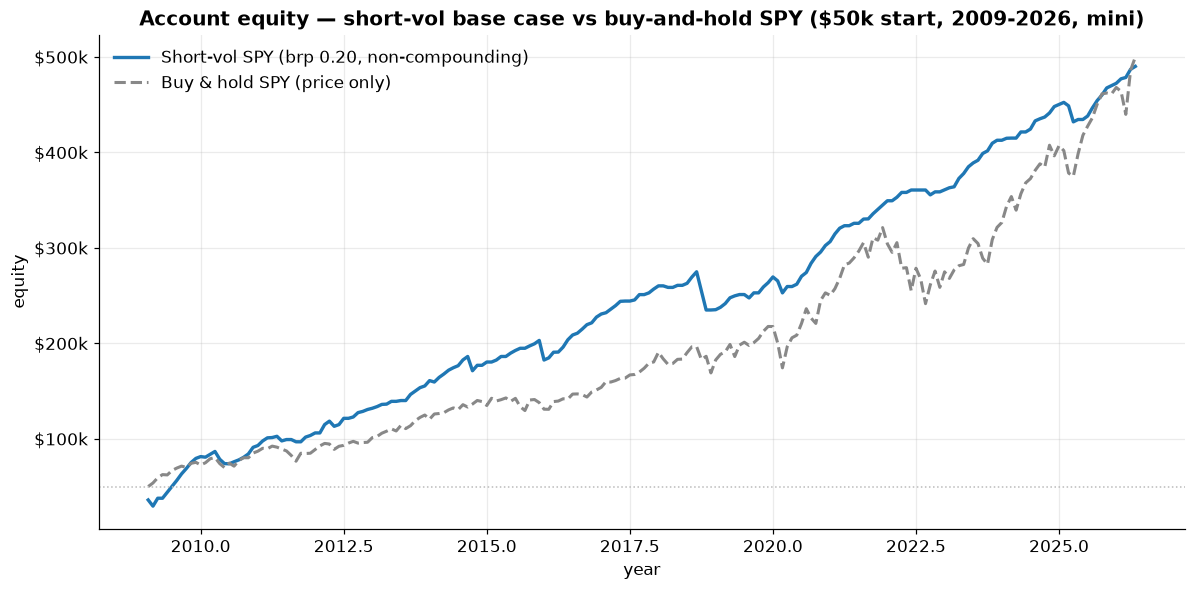

end equity  short-vol non-comp $490,109   buy-hold SPY $499,912
Near-identical total return. The short-vol edge is SMOOTHER MONTHLY returns (Sharpe ~1.56 vs ~0.7),
NOT a shallower max drawdown (next chart: buy-hold -25% actually BEATS short-vol -41%) and NOT raw return.
Fair-basis caveat: short-vol 'excess' EXCLUDES rf on ~half-idle cash (+); buy-hold price EXCLUDES
~1.8%/yr dividends (~+35% over 17y). On a fully fair basis buy-hold likely WINS on raw return here.


In [2]:
# Equity ($50k base + cumulative excess P&L) vs a simple buy-&-hold SPY benchmark.
fig, ax = plt.subplots()
ax.plot(eq.t, eq.spy020_noncomp, lw=2.2, color="#1f77b4", label="Short-vol SPY (brp 0.20, non-compounding)")
ax.plot(eq.t, eq.buyhold_spy,    lw=2.0, color="#888", ls="--", label="Buy & hold SPY (price only)")
ax.axhline(50_000, color="#bbb", lw=1, ls=":")
ax.yaxis.set_major_formatter(DOLLARS)
ax.set_title("Account equity — short-vol base case vs buy-and-hold SPY ($50k start, 2009-2026, mini)")
ax.set_xlabel("year"); ax.set_ylabel("equity"); ax.legend(loc="upper left")
fig.tight_layout(); plt.show()

end_nc, end_bh = eq.spy020_noncomp.iloc[-1], eq.buyhold_spy.iloc[-1]
print(f"end equity  short-vol non-comp ${end_nc:,.0f}   buy-hold SPY ${end_bh:,.0f}")
print("Near-identical total return. The short-vol edge is SMOOTHER MONTHLY returns (Sharpe ~1.56 vs ~0.7),")
print("NOT a shallower max drawdown (next chart: buy-hold -25% actually BEATS short-vol -41%) and NOT raw return.")
print("Fair-basis caveat: short-vol 'excess' EXCLUDES rf on ~half-idle cash (+); buy-hold price EXCLUDES")
print("~1.8%/yr dividends (~+35% over 17y). On a fully fair basis buy-hold likely WINS on raw return here.")


## 2. The compounding question — *what if I scale risk with equity?*

Today each rung risks `base_risk_pct × the ORIGINAL $50k`, **forever** — non-compounding, so equity grows ~linearly and the banked P&L just sits in cash. If instead you size each rung off **current equity**, returns compound geometrically (return-on-risk is scale-invariant ⇒ compounding = cumprod of the same monthly returns). On paper $490k → **$100M** (CAGR 14%→55%). **This is a fantasy** — capacity and tail risk make it un-realisable (next chart).


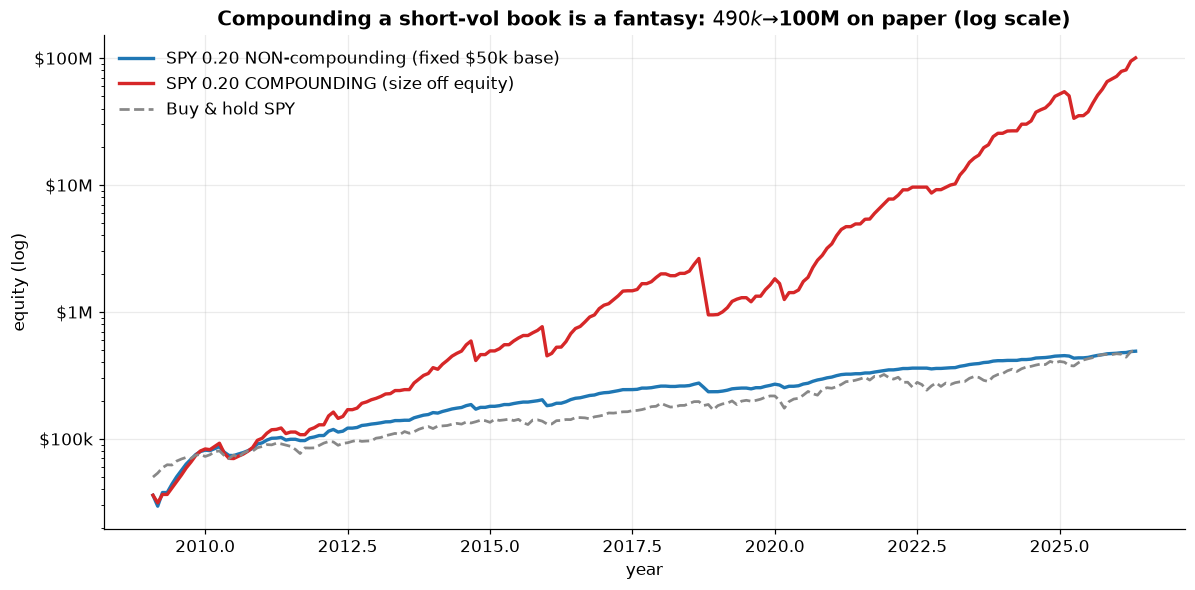

NON-compounding: end $       490,109  CAGR  14.1%
COMPOUNDING:     end $   100,254,353  CAGR  55.1%
The $100M is NOT real: (1) capacity — you can't scale SPY put-spread size to $100M at backtest prices;
(2) tail/ruin — see the drawdown chart: compounding's worst drawdown is -64% of peak (Nov-2018),
and this EXCLUDES 2008. Sizing INTO short vol as equity grows is how XIV / Volmageddon blew up.


In [3]:
# THE COMPOUNDING QUESTION: size each rung off CURRENT equity instead of the fixed $50k.
# Return-on-risk is scale-invariant, so compounding = cumprod of the same monthly returns.
# LOG scale because compounding is exponential.
fig, ax = plt.subplots()
ax.plot(eq.t, eq.spy020_noncomp, lw=2.2, color="#1f77b4", label="SPY 0.20 NON-compounding (fixed $50k base)")
ax.plot(eq.t, eq.spy020_comp,    lw=2.2, color="#d62728", label="SPY 0.20 COMPOUNDING (size off equity)")
ax.plot(eq.t, eq.buyhold_spy,    lw=1.8, color="#888", ls="--", label="Buy & hold SPY")
ax.set_yscale("log"); ax.yaxis.set_major_formatter(DOLLARS)
ax.set_title("Compounding a short-vol book is a fantasy: $490k → $100M on paper (log scale)")
ax.set_xlabel("year"); ax.set_ylabel("equity (log)"); ax.legend(loc="upper left")
fig.tight_layout(); plt.show()

def cagr(s): return (s.iloc[-1]/50_000)**(12/len(s)) - 1
print(f"NON-compounding: end ${eq.spy020_noncomp.iloc[-1]:>14,.0f}  CAGR {cagr(eq.spy020_noncomp)*100:5.1f}%")
print(f"COMPOUNDING:     end ${eq.spy020_comp.iloc[-1]:>14,.0f}  CAGR {cagr(eq.spy020_comp)*100:5.1f}%")
print("The $100M is NOT real: (1) capacity — you can't scale SPY put-spread size to $100M at backtest prices;")
print("(2) tail/ruin — see the drawdown chart: compounding's worst drawdown is -64% of peak (Nov-2018),")
print("and this EXCLUDES 2008. Sizing INTO short vol as equity grows is how XIV / Volmageddon blew up.")


## 3. Drawdowns — the fat left tail (and why compounding is a ruin machine)

Anchored at the $50k funding point, the non-compounding book's worst drawdown is **-41%** — the **March-2009 GFC**, when it sold puts straight into the crash. That is **deeper than buy-and-hold SPY's -25%** (2022): short-vol has a smoother *monthly* ride (higher Sharpe) but a **fatter left tail**. Compounding keeps the same percentage shocks on an ever-larger base, deepening the worst drawdown to **-64%** (Nov-2018) — and all of this **excludes 2008**. A leveraged short-vol book sized *into* the position is exactly how XIV / the Feb-2018 'Volmageddon' blew up.


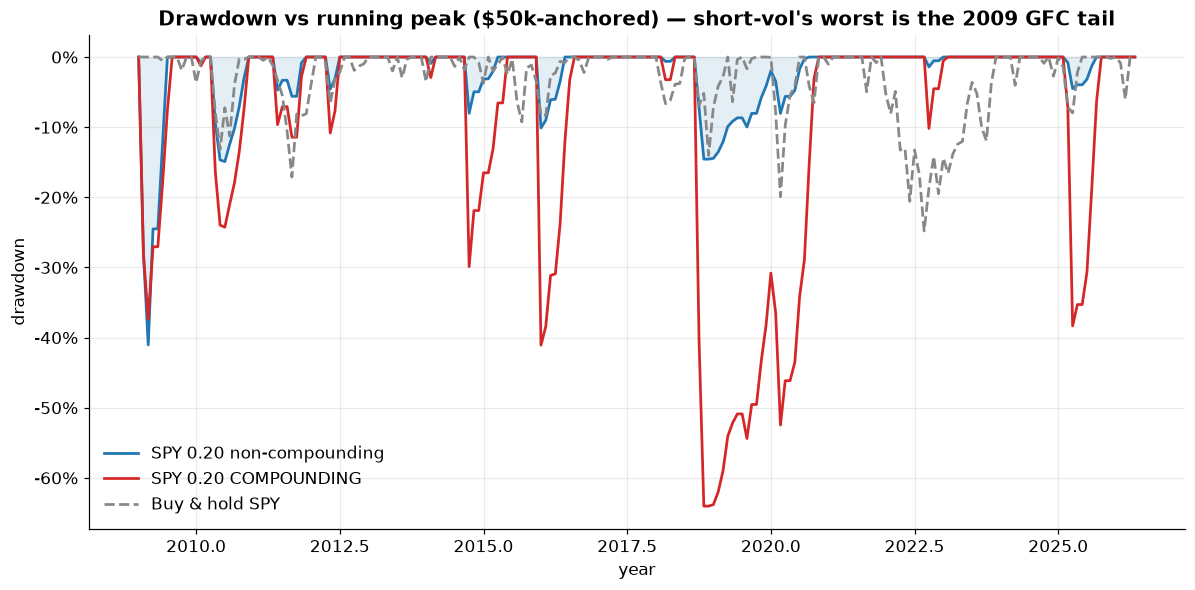

SPY 0.20 non-comp      maxDD (of peak)  -41.0%
SPY 0.20 COMPOUND      maxDD (of peak)  -64.0%
Buy & hold SPY         maxDD (of peak)  -24.8%
Short-vol non-comp -41% (Mar-2009 GFC) is DEEPER than buy-hold -25% (2022) — short-vol has a
smoother monthly ride (higher Sharpe) but a fatter LEFT TAIL. Compounding pushes it to -64%.


In [4]:
# Underwater (drawdown) curves: drawdown = equity / running-peak - 1.
# Underwater curves ANCHORED at the $50k funding point, so the early-2009 GFC drop
# (the strategy sold puts straight into the crash) is captured, not hidden.
t0 = eq.t.iloc[0] - 1 / 12.0
T = np.concatenate([[t0], eq.t.values])
def under(s):
    a = np.concatenate([[50_000.0], s.values])
    return a / np.maximum.accumulate(a) - 1.0
fig, ax = plt.subplots()
for c, color, ls, lbl in [("spy020_noncomp", "#1f77b4", "-", "SPY 0.20 non-compounding"),
                          ("spy020_comp", "#d62728", "-", "SPY 0.20 COMPOUNDING"),
                          ("buyhold_spy", "#888", "--", "Buy & hold SPY")]:
    ax.plot(T, under(eq[c]), color=color, lw=1.8, ls=ls, label=lbl)
ax.fill_between(T, under(eq.spy020_noncomp), 0, color="#1f77b4", alpha=0.12)
ax.yaxis.set_major_formatter(PCT)
ax.set_title("Drawdown vs running peak ($50k-anchored) — short-vol's worst is the 2009 GFC tail")
ax.set_xlabel("year"); ax.set_ylabel("drawdown"); ax.legend(loc="lower left")
fig.tight_layout(); plt.show()

for name, c in [("SPY 0.20 non-comp", "spy020_noncomp"), ("SPY 0.20 COMPOUND", "spy020_comp"),
                ("Buy & hold SPY", "buyhold_spy")]:
    print(f"{name:22s} maxDD (of peak) {under(eq[c]).min()*100:6.1f}%")
print("Short-vol non-comp -41% (Mar-2009 GFC) is DEEPER than buy-hold -25% (2022) — short-vol has a")
print("smoother monthly ride (higher Sharpe) but a fatter LEFT TAIL. Compounding pushes it to -64%.")


## 4. base_risk_pct frontier — the master dial (single-name SPX & SPY)

`base_risk_pct` sets per-rung risk → drives utilisation, skip-rate, and the return/drawdown trade-off. **SPY @ 0.20** (Sharpe 1.56, ~0 skips) is the granular recommendation; **SPX** is lumpier (~31%/contract) but reaches higher Sharpe at the cost of deeper early drawdowns.


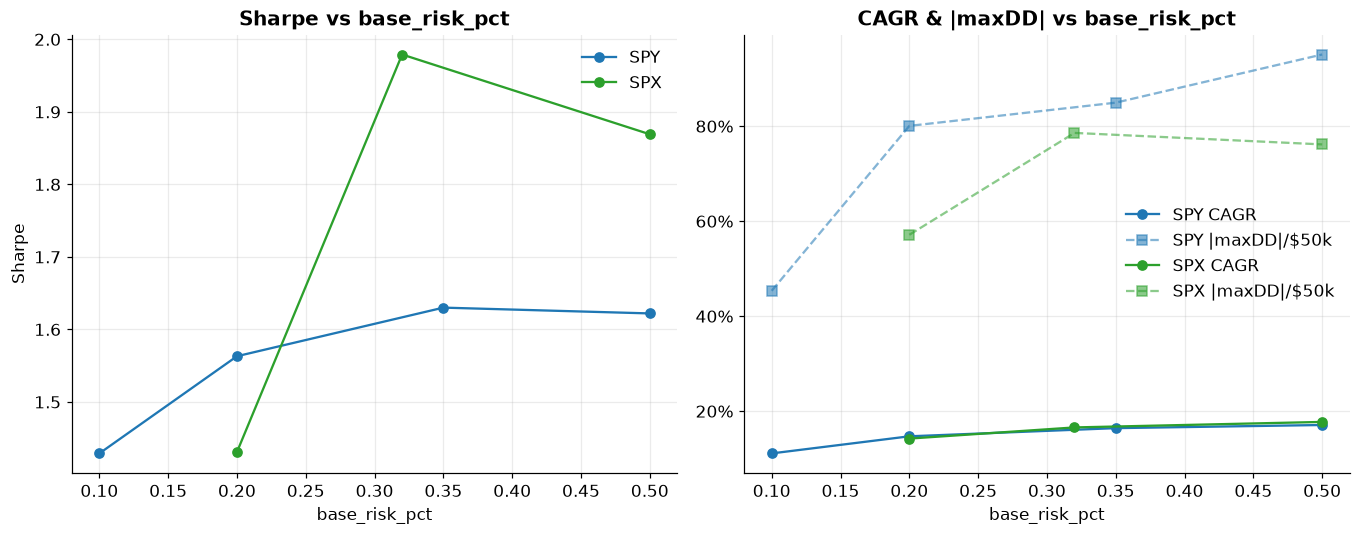

,vehicle,base_risk_pct,sharpe,cagr_gross,maxdd_dollars,maxdd_pct,util_mean,util_peak,skip_rate,fill_rate,win_rate,breach_rate,n_rungs,entries_per_yr
0,SPX,0.20,1.431,0.142,-28565.0,-0.571,0.313,0.999,0.004,0.978,0.914,0.111,279,17.9
1,SPX,0.32,1.979,0.166,-39291.0,-0.786,0.494,0.999,0.145,0.782,0.929,0.092,325,18.9
2,SPX,0.50,1.869,0.177,-38081.0,-0.762,0.606,1.000,0.305,0.554,0.932,0.088,296,17.1
3,SPY,0.10,1.429,0.111,-22672.0,-0.453,0.242,0.587,0.000,1.000,0.903,0.119,463,26.8
4,SPY,0.20,1.563,0.147,-40028.0,-0.801,0.488,1.000,0.000,0.961,0.904,0.117,478,27.6
5,SPY,0.35,1.630,0.164,-42476.0,-0.850,0.635,1.000,0.158,0.710,0.907,0.117,410,23.7
6,SPY,0.50,1.622,0.171,-47545.0,-0.951,0.702,1.000,0.262,0.543,0.911,0.111,360,20.8


In [5]:
# base_risk_pct frontier — the master dial. Single-name SPX & SPY, mini data, base-only.
d = mini.copy()
d["entries_per_yr"] = (d.n_rungs / d.years).round(1)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for veh, col in [("SPY", "#1f77b4"), ("SPX", "#2ca02c")]:
    g = d[d.vehicle == veh].sort_values("base_risk_pct")
    axes[0].plot(g.base_risk_pct, g.sharpe, "o-", color=col, label=veh)
    axes[1].plot(g.base_risk_pct, g.cagr_gross, "o-", color=col, label=f"{veh} CAGR")
    axes[1].plot(g.base_risk_pct, -g.maxdd_pct, "s--", color=col, alpha=0.55, label=f"{veh} |maxDD|/$50k")
axes[0].set_title("Sharpe vs base_risk_pct"); axes[0].set_xlabel("base_risk_pct"); axes[0].set_ylabel("Sharpe"); axes[0].legend()
axes[1].set_title("CAGR & |maxDD| vs base_risk_pct"); axes[1].set_xlabel("base_risk_pct")
axes[1].yaxis.set_major_formatter(PCT); axes[1].legend()
fig.tight_layout(); plt.show()
display(d[["vehicle","base_risk_pct","sharpe","cagr_gross","maxdd_dollars","maxdd_pct",
           "util_mean","util_peak","skip_rate","fill_rate","win_rate","breach_rate","n_rungs","entries_per_yr"]]
        .round(3).reset_index(drop=True))


## 5. The 3-name book (SPY+QQQ+IWM) — why diversifying *hurts*

The 28-config sweep's Sharpe ceiling is ~1.0-1.18, **below single-name SPX 1.83**, because QQQ (1.01) and especially **IWM (0.44, -128% maxDD)** dilute the S&P sleeve. The overlay lifts raw return but not Sharpe (leverage, not edge). **Single-name S&P wins; drop IWM.**


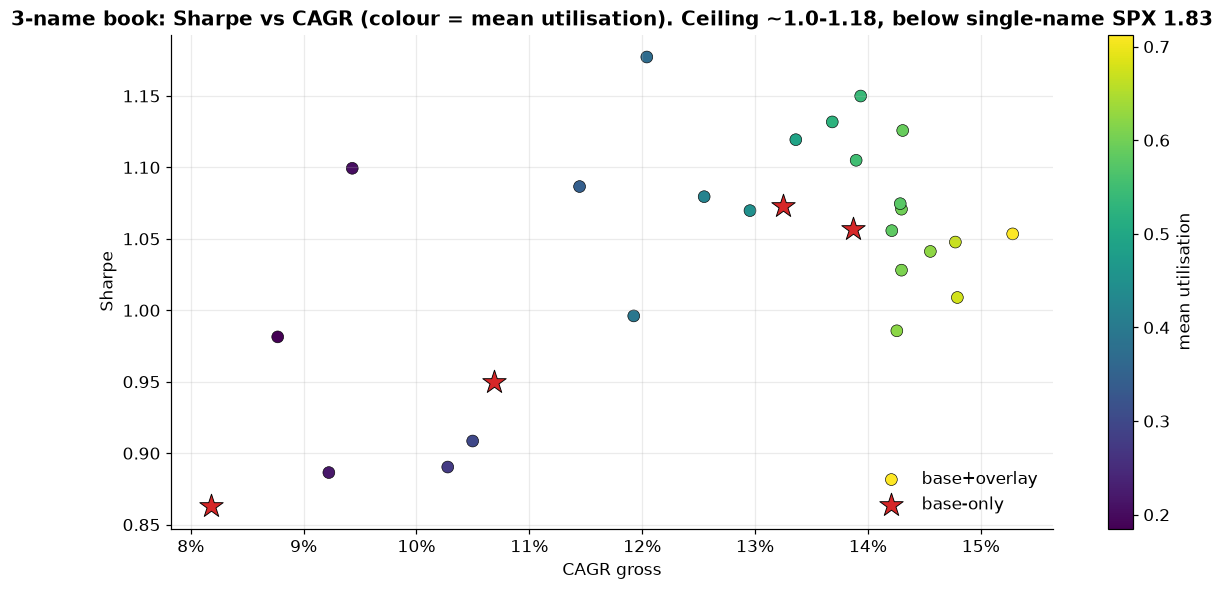

,base_risk_pct,overlay_mult,rich_threshold,cagr_gross,ann_return_gross,sharpe,maxdd_pct,util_mean,skip_rate,fill_rate
0,0.10,2.0,0.5,0.153,0.605,1.053,-1.012,0.713,0.342,0.420
1,0.08,2.0,0.5,0.148,0.557,1.009,-0.999,0.676,0.294,0.503
2,0.10,1.0,0.5,0.148,0.555,1.048,-0.992,0.668,0.250,0.566
3,0.10,2.0,1.0,0.146,0.534,1.041,-0.922,0.623,0.185,0.575
4,0.10,1.0,1.5,0.143,0.512,1.126,-0.844,0.589,0.112,0.792
5,0.10,1.0,1.0,0.143,0.511,1.028,-0.958,0.609,0.151,0.689
6,0.10,2.0,1.5,0.143,0.511,1.071,-0.844,0.598,0.138,0.740
7,0.08,2.0,1.0,0.143,0.510,1.075,-0.929,0.576,0.143,0.666
8,0.08,1.0,0.5,0.143,0.507,0.986,-0.955,0.621,0.189,0.667
9,0.05,2.0,0.5,0.142,0.503,1.056,-0.856,0.581,0.165,0.706


In [6]:
# 3-name (SPY+QQQ+IWM) 28-config sweep — base-only baselines + overlay grid.
base = sweep[sweep.overlay_enabled == 0].sort_values("base_risk_pct")
ovl  = sweep[sweep.overlay_enabled == 1].sort_values("cagr_gross", ascending=False)
fig, ax = plt.subplots()
sc = ax.scatter(ovl.cagr_gross, ovl.sharpe, c=ovl.util_mean, cmap="viridis", s=60, edgecolor="k", lw=0.4, label="base+overlay")
ax.scatter(base.cagr_gross, base.sharpe, marker="*", s=260, color="#d62728", edgecolor="k", lw=0.6, label="base-only", zorder=5)
ax.xaxis.set_major_formatter(PCT)
ax.set_title("3-name book: Sharpe vs CAGR (colour = mean utilisation). Ceiling ~1.0-1.18, below single-name SPX 1.83")
ax.set_xlabel("CAGR gross"); ax.set_ylabel("Sharpe"); ax.legend(loc="lower right")
fig.colorbar(sc, label="mean utilisation"); fig.tight_layout(); plt.show()
display(ovl[["base_risk_pct","overlay_mult","rich_threshold","cagr_gross","ann_return_gross",
             "sharpe","maxdd_pct","util_mean","skip_rate","fill_rate"]].head(12).round(3).reset_index(drop=True))


## Findings

1. **Base case is real & current:** capital-blind Sharpe **1.652** through 2026-06-18.
2. **vs buy-and-hold (the humbling one):** non-compounding short-vol ≈ buy-hold SPY in total return ($490k vs $500k), and on a fair basis buy-hold likely **wins** on raw return. Short-vol's max drawdown (**-41%**, 2009 GFC) is **deeper** than buy-hold's (**-25%**, 2022). The edge is the **smoother monthly ride** (Sharpe ~1.56 vs ~0.7) and **capital efficiency** (~half the $50k free), not raw return or drawdown. Its real role is a diversifier/overlay, not a standalone return engine.
3. **Compounding is a trap:** mathematically 14%→55% CAGR ($490k→$100M), but -64% drawdowns, finite capacity, and short-vol tail risk make full equity-scaling a ruin machine. Sub-linear scaling / a fixed dollar risk cap is the only safe middle ground.
4. **Single-name S&P beats the 3-name blend** (IWM is the drag). base_risk_pct is the real lever; the overlay is leverage, not edge.
5. **Recommended (if deployed):** SPY @ base_risk_pct ≈ 0.20, non-compounding (or sub-linear), gate ramp+ (idle when vol cheap — as it is now: live signal SKIP, vrp_z -1.95). Size it as a risk-adjusted/diversifying sleeve, not expecting it to beat buy-and-hold on raw return.
